### 1. Configuração Inicial de Pastas

In [2]:
import os
import shutil
from PIL import Image

# Defina o nome da pasta de exemplo
source_folder = '/content/drive/MyDrive/Foto_Origem/'
output_folder = '/content/drive/MyDrive/Foto_relatorio'

# Crie a pasta de origem se ela não existir
if not os.path.exists(source_folder):
    print(f"Aviso: A pasta de origem '{source_folder}' não foi encontrada. Verifique o caminho ou se o Drive está montado corretamente.")
else:
    print(f"Usando a pasta de origem: '{source_folder}'.")

# Crie a pasta de saída (e limpe se já existir de uma execução anterior)
if os.path.exists(output_folder):
    print(f"Limpando a pasta de saída existente: '{output_folder}'.")
    shutil.rmtree(output_folder)
os.makedirs(output_folder)
print(f"Pasta de saída '{output_folder}' criada (ou limpa).")

Usando a pasta de origem: '/content/drive/MyDrive/Foto_Origem/'.
Limpando a pasta de saída existente: '/content/drive/MyDrive/Foto_relatorio'.
Pasta de saída '/content/drive/MyDrive/Foto_relatorio' criada (ou limpa).


### 2. Listagem e Seleção Interativa das Fotos

Fotos disponíveis para seleção:



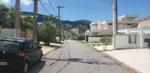
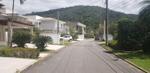
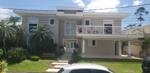
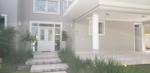
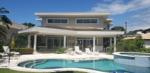
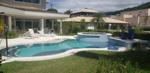
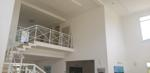
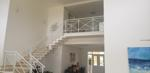
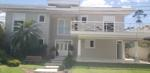

Por favor, digite os NÚMEROS das fotos que deseja usar, na ordem desejada, separados por vírgula (ex: 3,4,1):


Textarea(value='', description='Ordem:', layout=Layout(height='auto', width='50%'), placeholder='Ex: 3,4,1')

Button(description='Confirmar Seleção', style=ButtonStyle())

Output()

In [3]:
import os
from PIL import Image
from IPython.display import display, HTML
import io
import base64
import ipywidgets as widgets
from IPython.display import clear_output # Para limpar a saída e mostrar mensagens de feedback

# Variável global para armazenar as fotos ordenadas, acessível após a interação do widget
ordered_photos = []

def list_image_files(folder_path):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')
    image_files = []
    for file_name in sorted(os.listdir(folder_path)): # Ordena por nome para consistência
        if file_name.lower().endswith(image_extensions):
            image_files.append(file_name)
    return image_files

# Liste os arquivos de imagem na pasta de origem
available_photos = list_image_files(source_folder)

# Função que será chamada quando o botão for clicado
def on_selection_button_clicked(b):
    global ordered_photos
    with output_widget:
        clear_output(wait=True) # Limpa a saída anterior no widget para mostrar o novo feedback
        selection_input = selection_textarea.value.strip()

        if not selection_input:
            print("Nenhuma foto selecionada. Por favor, insira os números.")
            return

        try:
            selected_indices = [int(idx.strip()) - 1 for idx in selection_input.split(',')]

            # Validação dos índices
            if not selected_indices:
                print("Nenhuma foto selecionada. Por favor, tente novamente.")
                return

            # Checar se todos os índices são válidos
            all_valid = True
            for idx in selected_indices:
                if not (0 <= idx < len(available_photos)):
                    print(f"Índice inválido: {idx+1}. Por favor, insira números entre 1 e {len(available_photos)}.")
                    all_valid = False
                    break
            if not all_valid:
                return

            # Crie a lista final de fotos selecionadas e ordenadas
            ordered_photos = [available_photos[i] for i in selected_indices]
            print("\nFotos selecionadas na ordem escolhida:")
            for i, photo_name in enumerate(ordered_photos):
                print(f"{i+1}. {photo_name}")
            print("\nProcesso de seleção concluído. Você pode prosseguir para a próxima célula.")

            # Desabilita os widgets após uma seleção bem-sucedida para evitar novas interações
            selection_textarea.disabled = True
            selection_button.disabled = True

        except ValueError:
            print("Entrada inválida. Por favor, digite apenas números separados por vírgula.")
        except Exception as e:
            print(f"Ocorreu um erro: {e}")

# Lógica principal de exibição e interação
if not available_photos:
    print(f"Nenhuma foto encontrada na pasta: {source_folder}")
else:
    print("Fotos disponíveis para seleção:")

    # Coleta os snippets HTML para cada foto para exibi-los em um grid
    photo_html_snippets = []
    for i, photo_name in enumerate(available_photos):
        full_image_path = os.path.join(source_folder, photo_name)
        if os.path.exists(full_image_path):
            try:
                img = Image.open(full_image_path)
                img.thumbnail((150, 150)) # Tamanho da miniatura aumentado
                buffer = io.BytesIO()
                output_format = img.format if img.format in ['PNG', 'JPEG', 'GIF'] else 'JPEG'
                img.save(buffer, format=output_format)
                img_base64 = base64.b64encode(buffer.getvalue()).decode()

                photo_html_snippets.append(f'''
                    <div style="display: flex; flex-direction: column; align-items: center; text-align: center; border: 1px solid #eee; padding: 8px; border-radius: 5px; background-color: #f9f9f9;">
                        <span style="font-weight: bold; margin-bottom: 4px; font-size: 0.9em;">{i+1}.</span>
                        <img src="data:image/{output_format.lower()};base64,{img_base64}" style="width: 150px; height: 150px; object-fit: contain; border: 1px solid #ddd; padding: 2px; background-color: white;">
                        <span style="margin-top: 4px; max-width: 160px; white-space: normal; word-wrap: break-word; font-size: 0.85em; color: #333;">{photo_name}</span>
                    </div>
                ''')
            except Exception as e:
                print(f"Erro ao gerar miniatura para '{photo_name}': {e}")
                photo_html_snippets.append(f'''
                    <div style="border: 1px solid #eee; padding: 8px; border-radius: 5px; background-color: #f9f9f9; text-align: center;">
                        <span style="font-weight: bold; font-size: 0.9em;">{i+1}.</span><br>
                        <span style="white-space: normal; word-wrap: break-word; font-size: 0.85em;">{photo_name}</span><br>
                        <span style="color: red; font-size: 0.75em;">(Erro ao carregar imagem)</span>
                    </div>
                ''')
        else:
            photo_html_snippets.append(f'''
                <div style="border: 1px solid #eee; padding: 8px; border-radius: 5px; background-color: #f9f9f9; text-align: center;">
                    <span style="font-weight: bold; font-size: 0.9em;">{i+1}.</span><br>
                    <span style="white-space: normal; word-wrap: break-word; font-size: 0.85em;">{photo_name}</span><br>
                    <span style="color: orange; font-size: 0.75em;">(Arquivo não encontrado)</span>
                </div>
            ''')

    # Exibe todas as fotos em um grid de duas colunas com um container rolável
    display(HTML(f'''
        <div style="max-height: 300px; overflow-y: auto; border: 1px solid #ccc; padding: 10px; border-radius: 8px; background-color: #fcfcfc;">
            <div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 15px;">
                {''.join(photo_html_snippets)}
            </div>
        </div>
    '''))

    print("Por favor, digite os NÚMEROS das fotos que deseja usar, na ordem desejada, separados por vírgula (ex: 3,4,1):")
    selection_textarea = widgets.Textarea(
        value='',
        placeholder='Ex: 3,4,1',
        description='Ordem:',
        disabled=False,
        layout=widgets.Layout(width='50%', height='auto')
    )
    selection_button = widgets.Button(description="Confirmar Seleção")
    output_widget = widgets.Output() # Widget para exibir mensagens de feedback

    selection_button.on_click(on_selection_button_clicked)

    # Exibe os widgets interativos
    display(selection_textarea, selection_button, output_widget)

# A lista `ordered_photos` será populada quando o botão for clicado.
# O usuário poderá então prosseguir para a próxima célula.

### 3. Cópia e Padronização das Fotos Selecionadas

In [4]:
import os
import shutil

if 'ordered_photos' in locals() and ordered_photos:
    print(f"\nCopiando e renomeando fotos para '{output_folder}'...")
    for i, original_file_name in enumerate(ordered_photos):
        source_path = os.path.join(source_folder, original_file_name)

        # Mantenha a extensão original do arquivo
        file_base, file_extension = os.path.splitext(original_file_name)
        new_file_name = f'Foto {i+1}{file_extension}'

        destination_path = os.path.join(output_folder, new_file_name)

        shutil.copy2(source_path, destination_path)
        print(f"Copiado '{original_file_name}' para '{new_file_name}'")
    print("\nProcesso concluído!")
    print(f"As fotos ordenadas estão disponíveis na pasta: {output_folder}")
else:
    print("Nenhuma foto foi selecionada ou a seleção falhou na etapa anterior. Nenhuma foto foi copiada.")


Copiando e renomeando fotos para '/content/drive/MyDrive/Foto_relatorio'...
Copiado 'FTS1.jpg' para 'Foto 1.jpg'
Copiado 'FTS2.jpg' para 'Foto 2.jpg'
Copiado 'FTS3.jpg' para 'Foto 3.jpg'
Copiado 'FTS4.jpg' para 'Foto 4.jpg'
Copiado 'FTS5.jpg' para 'Foto 5.jpg'

Processo concluído!
As fotos ordenadas estão disponíveis na pasta: /content/drive/MyDrive/Foto_relatorio


### 4. Montagem do Google Drive

In [5]:
# Esta célula monta o Google Drive, permitindo que o Colab acesse seus arquivos.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 5. Definição e Verificação de Caminhos (Imagens e Fundo)

In [6]:
import os

print("## 📸 Caminhos das Imagens Definidos")

# Defina aqui o caminho da sua pasta de fotos e da imagem de fundo
IMAGES_BASE_PATH = '/content/drive/MyDrive/Foto_relatorio'
background_image_path = '/content/drive/MyDrive/BASE_Projeto_FOTO/fundo_prefeitura.jpg'

# Garante que o caminho da pasta de fotos termine com uma barra
if not IMAGES_BASE_PATH.endswith('/'):
    IMAGES_BASE_PATH += '/'

print(f"Pasta de fotos: {IMAGES_BASE_PATH}")
print(f"Imagem de fundo: {background_image_path}")

# Verificação de existência dos caminhos
print("\n--- Verificação ---")
if os.path.exists(IMAGES_BASE_PATH):
    print(f"✅ Pasta de fotos '{IMAGES_BASE_PATH}' EXISTE.")
else:
    print(f"❌ ATENÇÃO! Pasta de fotos '{IMAGES_BASE_PATH}' NÃO ENCONTRADA. Verifique o caminho.")

if os.path.exists(background_image_path):
    print(f"✅ Imagem de fundo '{background_image_path}' EXISTE.")
else:
    print(f"❌ ATENÇÃO! Imagem de fundo '{background_image_path}' NÃO ENCONTRADA.")

## 📸 Caminhos das Imagens Definidos
Pasta de fotos: /content/drive/MyDrive/Foto_relatorio/
Imagem de fundo: /content/drive/MyDrive/BASE_Projeto_FOTO/fundo_prefeitura.jpg

--- Verificação ---
✅ Pasta de fotos '/content/drive/MyDrive/Foto_relatorio/' EXISTE.
✅ Imagem de fundo '/content/drive/MyDrive/BASE_Projeto_FOTO/fundo_prefeitura.jpg' EXISTE.


In [7]:
# Esta célula define uma função para listar todas as imagens da pasta especificada e a executa para detectar as imagens.
# Ela também filtra a imagem de fundo para que não seja incluída no relatório como uma foto comum.
import os
from fpdf import FPDF
from PIL import Image # Usado para obter dimensões da imagem, se necessário

# IMAGES_BASE_PATH e background_image_path já foram definidos na célula anterior (a9fbbffc)

def get_image_paths_and_filenames_in_folder(folder_path, extensions=['.jpg', '.jpeg', '.png']):
    """
    Lista todos os arquivos de imagem em um dado diretório, juntamente com seus nomes.
    Retorna uma lista de tuplas (caminho_completo_imagem, nome_do_arquivo), ordenada pelo nome do arquivo.
    """
    image_data = []
    if not os.path.exists(folder_path):
        print(f"Aviso: Pasta não encontrada: {folder_path}")
        return []

    sorted_filenames = sorted(os.listdir(folder_path)) # Garante uma ordem consistente

    for filename in sorted_filenames:
        full_path = os.path.join(folder_path, filename)

        # Ignora a imagem de fundo se o caminho completo dela corresponder ao arquivo atual
        if full_path == background_image_path:
            continue

        # Verifica a extensão do arquivo
        if any(filename.lower().endswith(ext) for ext in extensions):
            image_data.append((full_path, filename))
    return image_data

# Chamar a função para listar os arquivos de imagem, usando o IMAGES_BASE_PATH definido na célula anterior
raw_image_files_info = get_image_paths_and_filenames_in_folder(IMAGES_BASE_PATH)

print(f"Caminho da imagem de fundo: {background_image_path}")
print(f"Imagens detectadas (caminho completo, nome do arquivo): {raw_image_files_info}")

# A lista final 'photos_legends_full_path' será gerada em uma célula subsequente

Caminho da imagem de fundo: /content/drive/MyDrive/BASE_Projeto_FOTO/fundo_prefeitura.jpg
Imagens detectadas (caminho completo, nome do arquivo): [('/content/drive/MyDrive/Foto_relatorio/Foto 1.jpg', 'Foto 1.jpg'), ('/content/drive/MyDrive/Foto_relatorio/Foto 2.jpg', 'Foto 2.jpg'), ('/content/drive/MyDrive/Foto_relatorio/Foto 3.jpg', 'Foto 3.jpg'), ('/content/drive/MyDrive/Foto_relatorio/Foto 4.jpg', 'Foto 4.jpg'), ('/content/drive/MyDrive/Foto_relatorio/Foto 5.jpg', 'Foto 5.jpg')]


In [8]:
import re

print("\n--- VERIFICAÇÃO DE CARACTERES ESPECIAIS EM NOMES DE ARQUIVO ---")

has_special_chars = False
for full_path, filename in raw_image_files_info:
    # Regex para encontrar caracteres que não são letras, números, hífen, underscore, ponto ou espaço
    # Isso inclui caracteres acentuados ou outros símbolos
    if re.search(r'[^a-zA-Z0-9_\-. ]', filename):
        print(f"ATENÇÃO: O arquivo '{filename}' contém caracteres especiais ou acentuados que podem causar problemas.")
        has_special_chars = True

if not has_special_chars:
    print("Nenhum caractere especial ou acentuado problemático detectado nos nomes dos arquivos.")
else:
    print("Recomenda-se renomear os arquivos listados acima para evitar problemas de codificação ou compatibilidade.")


--- VERIFICAÇÃO DE CARACTERES ESPECIAIS EM NOMES DE ARQUIVO ---
Nenhum caractere especial ou acentuado problemático detectado nos nomes dos arquivos.


### 6. Definição da Ordem das Fotos e Legendas para o PDF

In [9]:
# Esta célula define a ordem final das fotos para o relatório e gera as legendas iniciais para cada uma.
# A ordem das fotos agora é definida pela seleção interativa na célula anterior (Seção 2).

# A lista 'raw_image_files_info' contém tuplas (caminho_completo, nome_do_arquivo) de todas as fotos detectadas.
# 'ordered_photos' (da célula anterior) contém os nomes dos arquivos na ordem e seleção desejadas pelo usuário.

# A variável 'output_folder' (que é o IMAGES_BASE_PATH) contém a pasta onde as fotos foram renomeadas.

# Verifica se 'ordered_photos' foi populada pela interação do usuário
if 'ordered_photos' not in globals() or not ordered_photos:
    print("Atenção: A lista 'ordered_photos' não foi encontrada ou está vazia.\nCertifique-se de ter executado a célula de 'Listagem e Seleção Interativa das Fotos' (Seção 2) e confirmado sua seleção.")
    # Como fallback, vamos gerar uma lista com base nos arquivos atualmente em IMAGES_BASE_PATH
    # Isso é um fallback, pode não ser a ordem desejada.
    fallback_image_files_info = get_image_paths_and_filenames_in_folder(IMAGES_BASE_PATH)
    photo_order_for_pdf = [filename for _, filename in fallback_image_files_info]
    print("Usando a ordem alfabética dos arquivos renomeados na pasta de saída como fallback.")

    # Para o fallback, precisamos criar os caminhos completos diretamente dos arquivos já na pasta de saída
    photos_legends_full_path = []
    for i, (full_path, filename) in enumerate(fallback_image_files_info):
        legend = ""
        if i < len(default_initial_legends):
            legend = default_initial_legends[i]
        else:
            legend = "Detalhes do Imóvel"
        photos_legends_full_path.append((full_path, legend))

else:
    photo_order_for_pdf = ordered_photos

    print("--- ORDEM FINAL DAS FOTOS PARA O PDF (nomes dos arquivos originais) ---")
    for i, filename in enumerate(photo_order_for_pdf):
        print(f"{i+1}: {filename}")

    # --- GERAÇÃO DAS LEGENDAS INICIAIS E CAMINHOS COMPLETOS BASEADA NA ORDEM DEFINIDA ---

    # Defina as legendas padrão para as primeiras fotos
    default_initial_legends = [
        "Logradouro - Lado Direito",
        "Logradouro - Lado Esquerdo",
        "Fachada do Imóvel",
        "Numeração do Imóvel",
        "Detalhes do Imóvel"
    ]

    photos_legends_full_path = []
    for i, original_file_name in enumerate(photo_order_for_pdf):
        # Reconstroi o novo nome do arquivo e o caminho completo na pasta de saída
        file_extension = os.path.splitext(original_file_name)[1]
        renamed_file_name = f'Foto {i+1}{file_extension}'
        full_path_in_output = os.path.join(output_folder, renamed_file_name)

        legend = ""
        if i < len(default_initial_legends):
            legend = default_initial_legends[i]
        else:
            # Para as fotos restantes, use a legenda 'Detalhes do Imóvel'
            legend = "Detalhes do Imóvel"

        if os.path.exists(full_path_in_output):
            photos_legends_full_path.append((full_path_in_output, legend))
        else:
            print(f"Aviso: O arquivo renomeado '{renamed_file_name}' (original: '{original_file_name}') não foi encontrado em '{output_folder}'. Será ignorado.")

print("\n--- LISTA FINAL DE FOTOS E LEGENDAS INICIAIS (para PDF) ---")
for path, legend in photos_legends_full_path:
    print(f"Caminho: {path}\nLegenda: {legend}\n")

print("A lista 'photos_legends_full_path' foi gerada com a ordem e legendas iniciais.")

--- ORDEM FINAL DAS FOTOS PARA O PDF (nomes dos arquivos originais) ---
1: FTS1.jpg
2: FTS2.jpg
3: FTS3.jpg
4: FTS4.jpg
5: FTS5.jpg

--- LISTA FINAL DE FOTOS E LEGENDAS INICIAIS (para PDF) ---
Caminho: /content/drive/MyDrive/Foto_relatorio/Foto 1.jpg
Legenda: Logradouro - Lado Direito

Caminho: /content/drive/MyDrive/Foto_relatorio/Foto 2.jpg
Legenda: Logradouro - Lado Esquerdo

Caminho: /content/drive/MyDrive/Foto_relatorio/Foto 3.jpg
Legenda: Fachada do Imóvel

Caminho: /content/drive/MyDrive/Foto_relatorio/Foto 4.jpg
Legenda: Numeração do Imóvel

Caminho: /content/drive/MyDrive/Foto_relatorio/Foto 5.jpg
Legenda: Detalhes do Imóvel

A lista 'photos_legends_full_path' foi gerada com a ordem e legendas iniciais.


### 7. Definição da Classe Geradora de PDF

In [10]:
# Esta célula define a classe 'PDF' personalizada, que inclui funcionalidades como cabeçalho, rodapé,
# imagem de fundo e a adição de fotos centralizadas com ajuste de tamanho e legendas.
import os
from fpdf import FPDF
from PIL import Image

class PDF(FPDF):
    def __init__(self, background_path):
        super().__init__()
        self.background_path = background_path
        self.set_margins(20, 40, 20)
        self.set_auto_page_break(auto=True, margin=20)
        self.current_y = self.t_margin

    def header(self):
        if os.path.exists(self.background_path):
            self.image(self.background_path, x=0, y=0, w=self.w, h=self.h)
        self.set_font('Arial', 'B', 15)
        self.set_y(10)
        self.cell(0, 10, 'Relatório de Teste com Fotos', 0, 1, 'R')
        self.set_y(self.t_margin)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Página {self.page_no()}', 0, 0, 'C')

    def get_image_dimensions(self, path):
        try:
            with Image.open(path) as img:
                return img.size
        except FileNotFoundError:
            print(f"Arquivo de imagem não encontrado: {path}")
            return (0, 0)

    def add_centered_photo(self, img_path, legend, max_width, max_height):
        if not os.path.exists(img_path):
            print(f"Ignorando foto: {img_path} não encontrado.")
            return

        original_width, original_height = self.get_image_dimensions(img_path)
        if original_width == 0 or original_height == 0:
            print(f"Não foi possível obter dimensões da imagem ou imagem não encontrada: {img_path}")
            return

        # Calculate aspect ratio
        aspect_ratio = original_width / original_height

        # Determine dimensions to fit within max_width and max_height while maintaining aspect ratio
        # Start by assuming fitting by width
        actual_width = max_width
        actual_height = actual_width / aspect_ratio

        # If fitting by width makes the height too large, then fit by height
        if actual_height > max_height:
            actual_height = max_height
            actual_width = actual_height * aspect_ratio

        # Ensure that even after adjusting for height, the width doesn't accidentally exceed max_width
        if actual_width > max_width:
             actual_width = max_width
             actual_height = actual_width / aspect_ratio

        # Ensure that even after adjusting for width, the height doesn't accidentally exceed max_height
        if actual_height > max_height:
             actual_height = max_height
             actual_width = actual_height * aspect_ratio


        largura_pagina = self.w
        x_centralizado_img = (largura_pagina - actual_width) / 2

        space_after_image = 5
        estimated_legend_height = 8
        space_after_legend = 10

        self.set_y(self.current_y)

        self.image(img_path, x=x_centralizado_img, y=self.current_y, w=actual_width, h=actual_height)

        self.current_y += actual_height + space_after_image
        self.set_y(self.current_y)

        self.set_font('Arial', 'B', 11)
        # To center the multi_cell, set the x position before calling it.
        x_centralizado_legend = (largura_pagina - actual_width) / 2 # Center legend based on actual image width
        self.set_x(x_centralizado_legend)
        self.multi_cell(actual_width, estimated_legend_height, legend, 0, 'C')

        self.current_y = self.get_y() + space_after_legend

### 8. Geração e Salvamento Final do Relatório PDF

In [11]:
# Esta célula configura o layout das fotos por página, gera o PDF usando a classe definida acima
# e salva o arquivo final no seu Google Drive.
# Geração do PDF e salvamento no Google Drive
from google.colab import files # Mantido caso precise de download em outro momento, mas não usado aqui

# --- CONFIGURAÇÃO DO LAYOUT DE PÁGINAS ---
# Defina aqui a ordem e o agrupamento das fotos por página.
# Cada sublista contém os ÍNDICES das fotos (da lista 'photos_legends_full_path') para aquela página.
# Exemplo para: 2 fotos na pág 1, 2 fotos na pág 2, e 3 fotos por pág da pág 3 em diante.
# Lembre-se que os índices começam em 0.

# --- NOVAS CONFIGURAÇÕES PARA LAYOUT AUTOMÁTICO ---
PHOTOS_ON_FIRST_PAGE = 2
PHOTOS_ON_SECOND_PAGE = 2
PHOTOS_ON_SUBSEQUENT_PAGES = 3

# Gerar photo_layout_by_page automaticamente
photo_layout_by_page = []
num_total_photos = len(photos_legends_full_path)
current_photo_idx = 0

# Primeira página
if num_total_photos > 0:
    page_photos = []
    for _ in range(min(PHOTOS_ON_FIRST_PAGE, num_total_photos - current_photo_idx)):
        page_photos.append(current_photo_idx)
        current_photo_idx += 1
    if page_photos: # Adiciona apenas se houver fotos para esta página
        photo_layout_by_page.append(page_photos)

# Segunda página
if num_total_photos > current_photo_idx:
    page_photos = []
    for _ in range(min(PHOTOS_ON_SECOND_PAGE, num_total_photos - current_photo_idx)):
        page_photos.append(current_photo_idx)
        current_photo_idx += 1
    if page_photos: # Adiciona apenas se houver fotos para esta página
        photo_layout_by_page.append(page_photos)

# Páginas subsequentes
while num_total_photos > current_photo_idx:
    page_photos = []
    for _ in range(min(PHOTOS_ON_SUBSEQUENT_PAGES, num_total_photos - current_photo_idx)):
        page_photos.append(current_photo_idx)
        current_photo_idx += 1
    if page_photos: # Adiciona apenas se houver fotos para esta página
        photo_layout_by_page.append(page_photos)


# Cria uma instância da classe PDF com o caminho da imagem de fundo
pdf_final = PDF(background_image_path)

# Define constantes para cálculo de altura e largura máximas por foto
SPACE_AFTER_IMAGE = 5
ESTIMATED_LEGEND_HEIGHT = 8 # Altura estimada para a legenda (multi_cell pode variar)
SPACE_AFTER_LEGEND = 10
MIN_PHOTO_HEIGHT = 20 # Altura mínima para evitar fotos muito pequenas
MAX_PHOTO_WIDTH = 170 # Largura máxima permitida para a foto

# Itera sobre o layout definido para adicionar as fotos
for page_number, photo_indices_on_page in enumerate(photo_layout_by_page):
    pdf_final.add_page()
    pdf_final.current_y = pdf_final.t_margin

    num_photos_on_page = len(photo_indices_on_page)
    available_height = pdf_final.h - pdf_final.t_margin - pdf_final.b_margin

    # Calculate the total fixed overhead for all photo blocks on this page
    total_fixed_overhead = num_photos_on_page * (SPACE_AFTER_IMAGE + ESTIMATED_LEGEND_HEIGHT + SPACE_AFTER_LEGEND)

    # Calculate the height available for the photos themselves
    available_height_for_photos = available_height - total_fixed_overhead

    # Calculate individual photo max height, ensuring it's not too small
    max_height_per_photo = max(MIN_PHOTO_HEIGHT, available_height_for_photos / num_photos_on_page)

    for photo_idx in photo_indices_on_page:
        if photo_idx < len(photos_legends_full_path):
            img_path, legend = photos_legends_full_path[photo_idx]
            # Pass the calculated max height and the fixed max width to add_centered_photo
            pdf_final.add_centered_photo(img_path, legend, MAX_PHOTO_WIDTH, max_height_per_photo)
        else:
            print(f"Aviso: Índice de foto {photo_idx} fora dos limites de 'photos_legends_full_path'. Ignorando.")

# Define o nome do arquivo de saída com o caminho completo para o Google Drive
# Agora salvando na source_folder, conforme solicitado.
output_filename_drive = os.path.join(source_folder, 'relatorio_prefeitura_final.pdf')
pdf_final.output(output_filename_drive)

print(f"PDF '{output_filename_drive}' gerado e salvo com sucesso no seu Google Drive.")

PDF '/content/drive/MyDrive/Foto_Origem/relatorio_prefeitura_final.pdf' gerado e salvo com sucesso no seu Google Drive.


In [12]:
import shutil
import os

# Apaga a pasta temporária de saída APENAS se o usuário confirmar
if os.path.exists(output_folder):
    confirm = input(f"Deseja deletar a pasta temporária '{output_folder}'? (s/n): ")
    if confirm.lower() == 's':
        shutil.rmtree(output_folder)
        print(f"Pasta temporária '{output_folder}' deletada com sucesso.")
    else:
        print(f"A exclusão da pasta temporária '{output_folder}' foi cancelada.")
else:
    print(f"Pasta temporária '{output_folder}' não encontrada para deletar.")

Deseja deletar a pasta temporária '/content/drive/MyDrive/Foto_relatorio'? (s/n): n
A exclusão da pasta temporária '/content/drive/MyDrive/Foto_relatorio' foi cancelada.
